# E-Commerce Data Analysis Project

- Tools Used: Python, Pandas, Matplotlib, Seaborn
- Dataset: E-commerce sales transaction data
- Analysed By: Bhushan Khachane

Skills Demonstrated:
Python | Pandas | NumPy | Data Cleaning | EDA | Data Visualization | Business Analytics

## Project Goal
We have an e-commerce dataset containing:
- Customer information
- Product categories
- Sales
- Profit
- Region details
- Customer ratings

Our goal is to:
1. Understand the dataset
2. Clean the data
3. Analyze sales and profit
4. Study customer behavior
5. Create charts
6. Find business insights


## Step 1: Installing & Importing Libraries


In [38]:
# %pip install matplotlib  # Install matplotlib for data visualization
# %pip install seaborn     # Install seaborn for statistical data visualization
# %pip install plotly      # Install plotly for interactive data visualization


import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Loading Dataset

We load the CSV file into a DataFrame.

A DataFrame is simply a table made of rows and columns.


In [39]:
df = pd.read_csv('final DT_1B.csv')

## Step 3: Understand the Dataset

Before cleaning data, inspected it.

Questions:
- How many rows and columns exist?
- Which columns are available?
- Are there missing values?
- Are there duplicate rows?


In [40]:
print("Dataset Shape:",df.shape) # Print the number of rows and columns in the dataset

print("\nColumns:",(df.columns.tolist()))  # Print the list of column names in the dataset

print("\nMissing Values:") 
print(df.isnull().sum())  # Print the count of missing values in each column

print("\nDuplicate Rows:", df.duplicated().sum()) # Print the count of duplicate rows in the dataset

Dataset Shape: (200, 9)

Columns: ['Order_ID', 'Order_Date', 'Region', 'Product_Category', 'Sales', 'Profit', 'Quantity', 'Customer_Age', 'Customer_Rating']

Missing Values:
Order_ID             0
Order_Date           0
Region              15
Product_Category    15
Sales               15
Profit              15
Quantity             0
Customer_Age        15
Customer_Rating     15
dtype: int64

Duplicate Rows: 0


### Statistical Summary

This helps us understand:
- Average values
- Minimum values
- Maximum values
- Distribution of data


In [41]:
df.describe() # shows the statistical summery of the dataset, including count, mean, standard deviation, minimum, and maximum values for each numerical column.

,Order_ID,Sales,Profit,Quantity,Customer_Age,Customer_Rating
count,200.000000,185.000000,185.000000,200.000000,185.000000,185.000000
mean,1100.500000,23864.248649,4366.945946,10.020000,41.135135,2.856757
std,57.879185,15031.334826,5715.750379,5.817112,13.999538,1.149513
min,1001.000000,690.000000,-4588.000000,1.000000,18.000000,1.000000
25%,1050.750000,9507.000000,-252.000000,5.000000,28.000000,1.800000
50%,1100.500000,22509.000000,3924.000000,10.000000,43.000000,2.800000
75%,1150.250000,37131.000000,8923.000000,15.000000,54.000000,3.800000
max,1200.000000,49877.000000,14870.000000,19.000000,64.000000,5.000000


## Step 4: Data Cleaning

Data cleaning is one of the most important tasks.

We will:
- Convert dates into proper format
- Fill missing values
- Remove duplicate rows

### Why use Median?

Median is safer than average when extreme values exist.


In [42]:
# cd is copied data

cd = df.copy() 
# created a copy of the original dataframe to work with, preserving the original data for reference or backup.

cd["Order_Date"] = pd.to_datetime(cd["Order_Date"])  
# convert the "Order_Date" column to datetime format for easier manipulation and analysis of date-related data.

cd["Region"] = cd["Region"].fillna("Unknown") 
# fill missing values in the "Region" column with "Unknown" to indicate that the region information is not available for those entries.

cd["Product_Category"] = cd["Product_Category"].fillna("Unknown")

cd["Sales"] = cd["Sales"].fillna(cd["Sales"].median())

cd["Profit"] = cd["Profit"].fillna(cd["Profit"].median())

cd["Customer_Age"] = cd["Customer_Age"].fillna(cd["Customer_Age"].median())
# fill missing values in the "Customer_Age" column with the median age, since age can have outliers.

cd["Customer_Rating"] = cd["Customer_Rating"].fillna(cd["Customer_Rating"].median())
# fill missing values in the "Customer_Rating" column with the median rating.

cd = cd.drop_duplicates() 
# remove duplicate rows from the dataset to ensure that each entry is unique and to prevent skewing the analysis with repeated data.


## Step 5: Save Cleaned Dataset

Keeping a cleaned copy is a good practice.


In [ ]:
cd.to_csv("cleaned_ecommerce_data.csv", index=False)  
# save the CLEANED dataset (cd) to a new CSV file named "cleaned_ecommerce_data.csv" without including the index column in the output file.

print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


## Step 6: Sales Analysis

We want to know:
- Total sales
- Average sales
- Highest sales order
- Lowest sales order


In [ ]:
total_sales = cd["Sales"].sum() 
# calculate the total sales by summing up all the values in the "Sales" column of the cleaned dataset.

average_sales = cd["Sales"].mean()
# calculate the average sales by taking the mean of the values in the "Sales" column of the cleaned dataset.

highest_sales = cd["Sales"].max()
# calculate the highest sales by finding the maximum value in the "Sales" column of the cleaned dataset.

lowest_sales = cd["Sales"].min()
# calculate the lowest sales by finding the minimum value in the "Sales" column of the cleaned dataset.

print("Total Sales:", total_sales)
print("Average Sales:", average_sales)
print("Highest Sales:", highest_sales)
print("Lowest Sales:", lowest_sales)

Total Sales: 4752521.0
Average Sales: 23762.605
Highest Sales: 49877.0
Lowest Sales: 690.0


### Simple Interpretation

- Total Sales = Overall business revenue
- Average Sales = Average value per order


## Step 7: Profit Analysis

Profit is more important than sales.

A company can have high sales but low profit.


In [ ]:
profit_by_region = cd.groupby("Region")["Profit"].sum().sort_values(ascending=False)
# profit_by_region is a Series that contains the total profit for each region, and then sorting the results in descending order to show the regions with the highest profit first.

print(profit_by_region)

Region
East       268839.0
West       215462.0
North      164411.0
South      159674.0
Unknown     58359.0
Name: Profit, dtype: float64


### What does this tell us?

- Top region = Best profit contributor
- Bottom region = Needs improvement


## Step 8: Customer Analysis

We want to understand customers better.


In [ ]:
print("Average Customer Age:", cd["Customer_Age"].mean())
# calculate the average customer age by taking the mean of the values in the "Customer_Age" column of the cleaned dataset.

print("Average Customer Rating:", cd["Customer_Rating"].mean())
# calculate the average customer rating by taking the mean of the values in the "Customer_Rating" column of the cleaned dataset.

Average Customer Age: 41.13513513513514
Average Customer Rating: 2.8567567567567567


## Step 9: Monthly Sales Trend

This helps us identify:
- Good months
- Weak months
- Seasonal patterns


In [62]:
monthly_sales = (
    cd.assign(Month=cd["Order_Date"].dt.to_period("M").astype(str))
    .groupby("Month")["Sales"]
    .sum()
)
# create a new column "Month" by extracting the month from the "Order_Date" column, then group the data by this new "Month" column and sum the "Sales" for each month to get the total sales per month.
monthly_sales

Month
2025-01    763340.0
2025-02    773114.0
2025-03    789243.0
2025-04    708406.0
2025-05    707415.0
2025-06    665959.0
2025-07    345044.0
Name: Sales, dtype: float64

## Step 10: Visualization - Sales Distribution

This chart shows how sales values are spread.


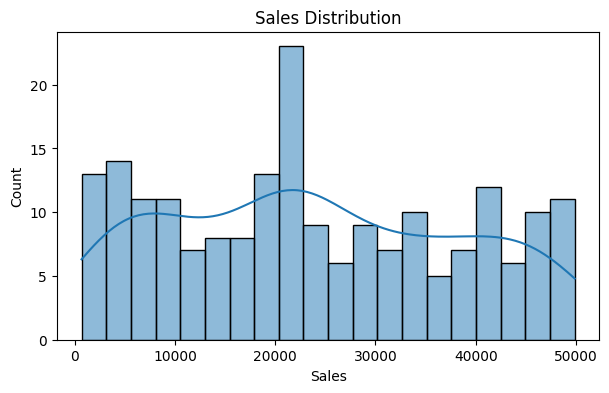

In [ ]:
plt.figure(figsize=(7,4)) 
# set the size of the plot to 7 inches wide and 4 inches tall for better visualization.

sns.histplot(cd["Sales"], bins=20, kde=True)
# create a histogram of the "Sales" column with 20 bins and overlay a kernel density estimate (KDE) to show the distribution of sales data.

plt.title("Sales Distribution")
# set the title of the plot to "Sales Distribution" to indicate what the plot represents.

plt.show()
# display the plot on the screen.

## Step 11: Visualization - Sales by Region

This chart compares regions.


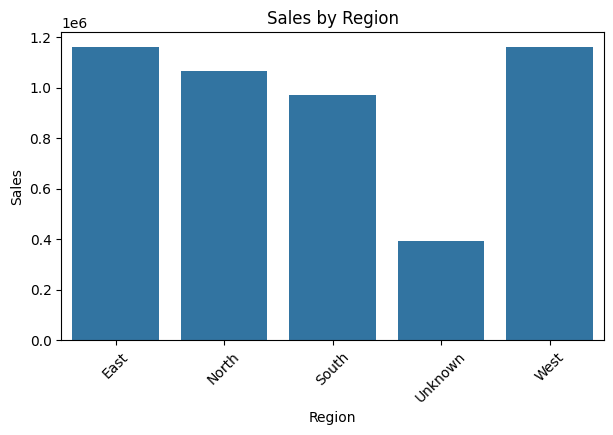

In [ ]:
region_sales = cd.groupby("Region")["Sales"].sum().reset_index()
# group the data by "Region", sum the "Sales" for each region, and reset the index to convert the resulting Series into a DataFrame for easier plotting.

plt.figure(figsize=(7,4)) 

sns.barplot(data=region_sales, x="Region", y="Sales") 
# create a bar plot using seaborn with "Region" on the x-axis and "Sales" on the y-axis, using the region_sales DataFrame as the data source to visualize the total sales for each region.

plt.title("Sales by Region")

plt.xticks(rotation=45)
# rotate the x-axis labels by 45 degrees to improve readability, especially if the region names are long.

plt.show()


## Step 12: Visualization - Sales vs Profit

This chart helps us understand the relationship between sales and profit.


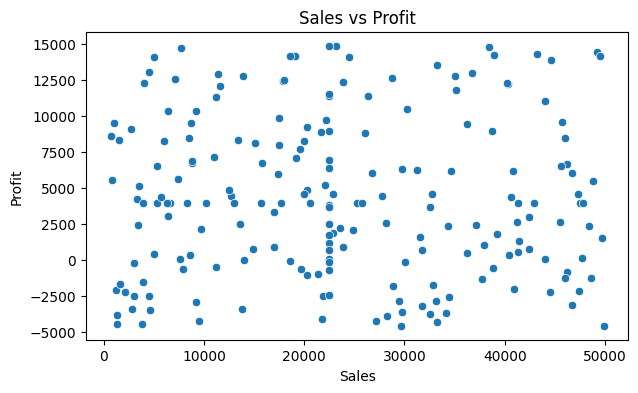

In [ ]:
plt.figure(figsize=(7,4))

sns.scatterplot(data=cd, x="Sales", y="Profit")
# create a scatter plot using seaborn with "Sales" on the x-axis and "Profit" on the y-axis, using the cleaned dataset (cd) as the data source to visualize the relationship between sales and profit.

plt.title("Sales vs Profit")

plt.show()

## Step 13: Quantity Analysis

Sales and profit tell us about money, but Quantity tells us about volume.

We want to know:
- How many total units were sold?
- Which product category sells the most units?


In [ ]:
total_quantity = cd["Quantity"].sum()
# calculate the total number of units sold across all orders.

quantity_by_category = cd.groupby("Product_Category")["Quantity"].sum().sort_values(ascending=False)
# group the data by "Product_Category", sum the "Quantity" for each category, and sort in descending order.

print("Total Units Sold:", total_quantity)
print("\nUnits Sold by Category:")
print(quantity_by_category)

plt.figure(figsize=(7,4))

sns.barplot(x=quantity_by_category.index, y=quantity_by_category.values)
# create a bar plot showing total units sold for each product category.

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.show()


### What does this tell us?

- Total units sold shows the overall scale of operations.
- The top category by quantity may not be the top category by profit — comparing the two can reveal whether you're selling a lot of low-margin items or a smaller number of high-margin ones.


## Step 14: NumPy Example

Using NumPy for basic calculations.


In [51]:
sales_array = np.array(cd["Sales"])

print("Maximum Sales:", np.max(sales_array))
print("Minimum Sales:", np.min(sales_array))
print("Average Sales:", np.mean(sales_array))

Maximum Sales: 49877.0
Minimum Sales: 690.0
Average Sales: 23762.605


## Final Business Insights

Based on the analysis above, here's what the data tells us about this business:

**1. Overall performance**
The business generated **$4,752,521** in total sales across 200 orders, averaging **$23,762.61** per order. Order values range widely — from **$690** to **$49,877** — showing a mix of small and very large orders.

**2. Best-performing region**
**East** is the strongest region by profit, contributing **$268,839**, ahead of West (**$215,462**), North (**$164,411**), and South (**$159,674**).

**3. A region that needs attention**
Orders with missing/"Unknown" region data contributed only **$58,359** in profit — the lowest of any group. Improving how region data is captured at the point of sale would give a more complete and reliable view of regional performance.

**4. Customer demographics**
The average customer is about **41 years old**, suggesting the core customer base is middle-aged — useful context when planning marketing campaigns or product positioning.

**5. Customer satisfaction is a concern**
The average customer rating is **2.86 out of 5** — below the midpoint. This is a signal worth digging into further (e.g. product quality, delivery experience, or support issues) before scaling up sales and marketing efforts.

**6. Sales volume vs. profit (Quantity Analysis)**
Comparing units sold by category (Step 13) against profit by region (Step 7) helps reveal whether high-volume categories are also the most profitable, or whether some categories sell a lot but contribute relatively little to the bottom line.

### Recommendations
- **Double down on the East region**, which is the strongest profit driver — consider replicating whatever is working there (marketing mix, product assortment, etc.) in weaker regions.
- **Investigate the low average customer rating (2.86/5)** before scaling sales — growing volume on top of an unresolved satisfaction issue could amplify churn.
- **Tighten data collection** for Region and Product Category at checkout to shrink the "Unknown" segment and improve the accuracy of future analysis.
- **Use the monthly sales trend (Step 9)** to plan inventory, staffing, and promotions around peak months.
- **Re-examine low-quantity, high-profit categories** as candidates for expanded marketing, and high-quantity, low-profit categories as candidates for pricing or cost review.
